<a href="https://colab.research.google.com/github/jpbjoaopedro/sistemas-evoluidos-aplicados-a-robotica/blob/main/ava1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Biblioca que instala o YOLO

In [1]:
!pip install ultralytics

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

0: 448x640 2 persons, 1 cup, 1 knife, 4 spoons, 5 bowls, 2 ovens, 1 sink, 93.5ms
Speed: 7.0ms preprocess, 93.5ms inference, 36.2ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 2 persons, 1 cup, 1 knife, 4 spoons, 5 bowls, 2 ovens, 1 sink, 29.8ms
Speed: 2.5ms preprocess, 29.8ms inference, 0.5ms postprocess per image at shape (1, 3, 448, 640)
Tempo de inferência: 0.0386 segundos


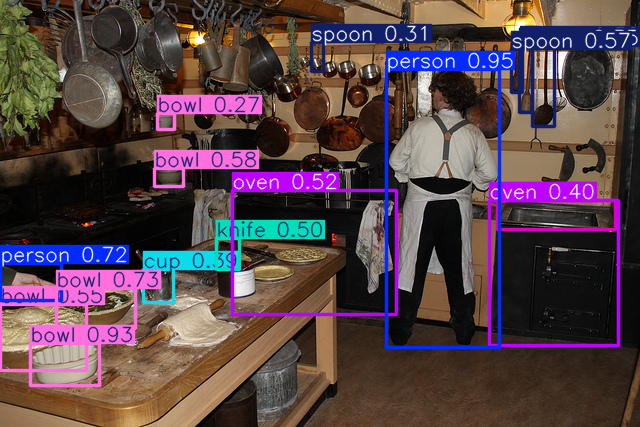

In [2]:
import requests
import cv2
import numpy as np
import time
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

url="http://images.cocodataset.org/val2017/000000397133.jpg" # @param {type:"string"}
response = requests.get(url)

image_array = np.asarray(bytearray(response.content), dtype=np.uint8)
img = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

# 2. Modelo
yoloModel = "yolo26m.pt" # @param ["yolo26n.pt", "yolo26s.pt", "yolo26m.pt", "yolo26l.pt", "yolo26x.pt"] {type:'string'}
model = YOLO(yoloModel)

# 3. Tempo de inferência
results = model(img)

start = time.perf_counter()
results = model(img)
end = time.perf_counter()

tempo = end - start
print(f"Tempo de inferência: {tempo:.4f} segundos")

# 4. Anotar imagem
annotated = results[0].plot()

# 5. Mostrar imagem (Colab)
cv2_imshow(annotated)